In [2]:
!pip install Biopython

     |████████████████████████████████| 2.3MB 7.3MB/s 


In [3]:
import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dropout, Activation, Flatten
from keras.layers import Embedding, LSTM, Dense, Bidirectional

from matplotlib import pyplot as plt

from Bio.Seq import Seq

### Read data

In [4]:
filename = "training_data.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [5]:
b = open('ghl_gold.fa','r')
bind = b.readlines()
b.close()

u = open('ghl_gold_random.fa','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [6]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [7]:
print(len(bind), len(unbind))

1400090 1400090


##### Reverse complement

In [8]:
bind_rev = list(range(len(bind)))

for i in range(len(bind)):
  seq = Seq(bind[i])
  rev = seq.reverse_complement()
  bind_rev[i] = str(rev)

unbind_rev = list(range(len(unbind)))

for i in range(len(unbind)):
  seq = Seq(unbind[i])
  rev = seq.reverse_complement()
  unbind_rev[i] = str(rev)

In [9]:
bind_fb = bind + bind_rev
unbind_fb = unbind + unbind_rev

In [10]:
bind_label = [1 for i in range(len(bind_fb))]
unbind_label = [0 for i in range(len(unbind_fb))]

In [11]:
bind_dict = {"seq":bind_fb, "label":bind_label}
unbind_dict = {"seq":unbind_fb, "label":unbind_label}

In [12]:
bind_df = pd.DataFrame(bind_dict)
unbind_df = pd.DataFrame(unbind_dict)

In [13]:
df = pd.concat([bind_df, unbind_df])

##### split the dataset

In [14]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [15]:
x = new_df.seq
y = new_df.label

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

##### One-hot Encoding

In [17]:
LE = LabelEncoder()
LE.fit(['A', 'C', 'G', 'T', 'N'])

LabelEncoder()

In [18]:
start = datetime.now()

for index, row in x_train.items():
  x_train[index] = LE.transform(list(row))

for index, row in x_test.items():
  x_test[index] = LE.transform(list(row))

x_train = to_categorical(x_train.values.tolist())
x_t = to_categorical(x_test.values.tolist())

y_train = to_categorical(y_train.values.tolist())
y_t = to_categorical(y_test.values.tolist())

end = datetime.now()
print("encoding running time : "+str(end-start))

encoding running time : 0:05:40.772291


### RNN model

In [19]:
model = Sequential()
model.add(LSTM(128, input_shape=(20, 5), return_sequences=True))
model.add(LSTM(128))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 20, 128)           68608     
_________________________________________________________________
lstm_1 (LSTM)                (None, 128)               131584    
_________________________________________________________________
dense (Dense)                (None, 64)                8256      
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 130       
Total params: 208,578
Trainable params: 208,578
Non-trainable params: 0
_________________________________________________________________


In [21]:
bi_model = Sequential()
bi_model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(20, 5)))
bi_model.add(Bidirectional(LSTM(64)))
bi_model.add(Dense(64, activation='relu'))
bi_model.add(Dropout(0.2))
bi_model.add(Dense(2, activation='softmax'))
bi_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [22]:
bi_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
bidirectional (Bidirectional (None, 20, 128)           35840     
_________________________________________________________________
bidirectional_1 (Bidirection (None, 128)               98816     
_________________________________________________________________
dense_2 (Dense)              (None, 64)                8256      
_________________________________________________________________
dropout_1 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 2)                 130       
Total params: 143,042
Trainable params: 143,042
Non-trainable params: 0
_________________________________________________________________


In [23]:
history = model.fit(x_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
112008/112008 [==============================] - 709s 6ms/step - loss: 0.3482 - accuracy: 0.8473 - val_loss: 0.3122 - val_accuracy: 0.8648
Epoch 2/10
112008/112008 [==============================] - 698s 6ms/step - loss: 0.3103 - accuracy: 0.8664 - val_loss: 0.3067 - val_accuracy: 0.8672
Epoch 3/10
112008/112008 [==============================] - 698s 6ms/step - loss: 0.3060 - accuracy: 0.8680 - val_loss: 0.3072 - val_accuracy: 0.8676
Epoch 4/10
112008/112008 [==============================] - 698s 6ms/step - loss: 0.3032 - accuracy: 0.8695 - val_loss: 0.3048 - val_accuracy: 0.8684
Epoch 5/10
112008/112008 [==============================] - 698s 6ms/step - loss: 0.3018 - accuracy: 0.8699 - val_loss: 0.3042 - val_accuracy: 0.8685
Epoch 6/10
112008/112008 [==============================] - 694s 6ms/step - loss: 0.3012 - accuracy: 0.8704 - val_loss: 0.3040 - val_accuracy: 0.8689
Epoch 7/10
112008/112008 [==============================] - 683s 6ms/step - loss: 0.3003 - accuracy:

In [24]:
bi_history = bi_model.fit(x_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
112008/112008 [==============================] - 1092s 10ms/step - loss: 0.3488 - accuracy: 0.8474 - val_loss: 0.3118 - val_accuracy: 0.8653
Epoch 2/10
112008/112008 [==============================] - 1088s 10ms/step - loss: 0.3108 - accuracy: 0.8659 - val_loss: 0.3074 - val_accuracy: 0.8666
Epoch 3/10
112008/112008 [==============================] - 1084s 10ms/step - loss: 0.3064 - accuracy: 0.8680 - val_loss: 0.3050 - val_accuracy: 0.8681
Epoch 4/10
112008/112008 [==============================] - 1085s 10ms/step - loss: 0.3038 - accuracy: 0.8689 - val_loss: 0.3049 - val_accuracy: 0.8681
Epoch 5/10
112008/112008 [==============================] - 1065s 10ms/step - loss: 0.3022 - accuracy: 0.8699 - val_loss: 0.3036 - val_accuracy: 0.8686
Epoch 6/10
112008/112008 [==============================] - 1100s 10ms/step - loss: 0.3006 - accuracy: 0.8708 - val_loss: 0.3039 - val_accuracy: 0.8690
Epoch 7/10
112008/112008 [==============================] - 1113s 10ms/step - loss: 0.29

##### Evaluation

Accuracy

In [25]:
score = model.evaluate(x_t, y_t)
print("score = " + str(round(score[1],2)))

35003/35003 [==============================] - 114s 3ms/step - loss: 0.3040 - accuracy: 0.8690
score = 0.87


In [26]:
bi_score = bi_model.evaluate(x_t, y_t)
print("score = " + str(round(bi_score[1],2)))

35003/35003 [==============================] - 157s 4ms/step - loss: 0.3042 - accuracy: 0.8680
score = 0.87


loss-epoch curve

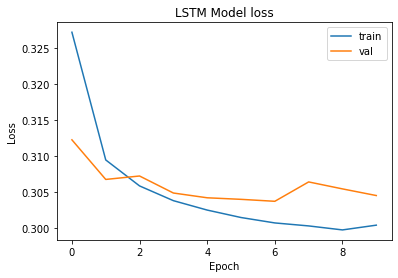

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('LSTM Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

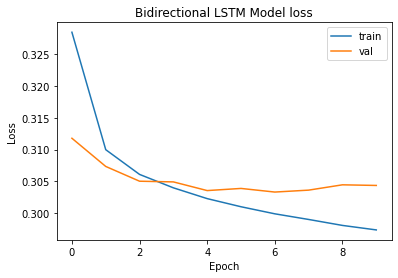

In [28]:
plt.plot(bi_history.history['loss'])
plt.plot(bi_history.history['val_loss'])
plt.title('Bidirectional LSTM Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [29]:
probs = model.predict(x_t)[:,1]
bi_probs = bi_model.predict(x_t)[:,1]

In [30]:
precision, recall, thresholds = precision_recall_curve(y_test.values, probs)
bi_precision, bi_recall, bi_thresholds = precision_recall_curve(y_test.values, bi_probs)

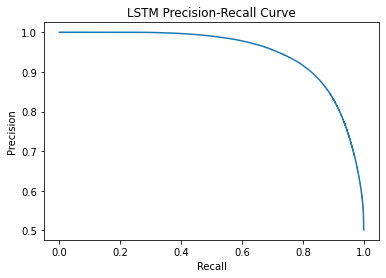

In [31]:
plt.plot(recall, precision)

plt.title('LSTM Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

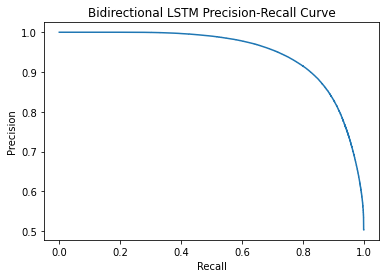

In [32]:
plt.plot(bi_recall, bi_precision)

plt.title('Bidirectional LSTM Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

ROC curve & AUC

In [33]:
auc = roc_auc_score(y_test.values, probs)
fpr, tpr, _ = roc_curve(y_test.values, probs)

bi_auc = roc_auc_score(y_test.values, bi_probs)
bi_fpr, bi_tpr, bi_ = roc_curve(y_test.values, bi_probs)

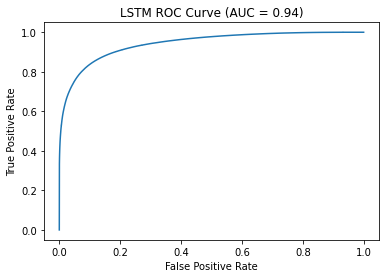

In [34]:
plt.plot(fpr, tpr)
plt.title('LSTM ROC Curve (AUC = ' + str(round(auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

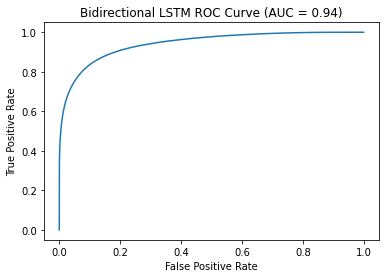

In [35]:
plt.plot(bi_fpr, bi_tpr)
plt.title('Bidirectional LSTM ROC Curve (AUC = ' + str(round(bi_auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()